In [143]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


## Setup

In [144]:
from dotenv import load_dotenv
load_dotenv()

True

In [145]:
# Load paths from .env file
dataset_dir = os.getenv("DATASET_DIR")
datasplits_dir = os.getenv("DATASPLITS_DIR")

# Patgs to the data splits files
train_file = os.path.join(datasplits_dir, "img_train.tsv")
val_file = os.path.join(datasplits_dir, "img_val.tsv")
test_file = os.path.join(datasplits_dir, "img_test.tsv")

# Load the data splits into pandas DataFrames
train_df = pd.read_csv(train_file, sep="\t")
val_df = pd.read_csv(val_file, sep="\t")
test_df = pd.read_csv(test_file, sep="\t")

In [146]:
train_df.shape

(12147, 5)

In [147]:
train_df.head(1)

,img_hash_str,image_path,image_info,image_human,image_damage
0,82dbe0ba8ec5d649,data_image/california_wildfires/11_10_2017/918...,informative,vehicle_damage,unknown


In [148]:
val_df.shape

(2603, 5)

In [149]:
val_df.head(1)

,img_hash_str,image_path,image_info,image_human,image_damage
0,853972f25b8b625c,data_image/california_wildfires/15_10_2017/919...,not_informative,not_humanitarian,unknown


In [150]:
test_df.shape

(2604, 5)

In [151]:
test_df.head(1)

,img_hash_str,image_path,image_info,image_human,image_damage
0,e83c974263db43a6,data_image/srilanka_floods/3_6_2017/8710543622...,informative,rescue_volunteering_or_donation_effort,unknown


## Hyperparameters

In [152]:
BATCH_SIZE = 32

## Label Encoding

In [153]:
label_encoders = {}
for col in ["image_info", "image_human", "image_damage"]:
    le = LabelEncoder()
    all_values = pd.concat([train_df[col], val_df[col], test_df[col]])
    le.fit(all_values)
    train_df[col] = le.transform(train_df[col])
    val_df[col] = le.transform(val_df[col])
    test_df[col] = le.transform(test_df[col])
    label_encoders[col] = le


## Data Loading

In [154]:
IMAGE_SIZE = (224, 224)

def load_image(path, label1, label2, label3):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = preprocess_input(img)
    return img, {"info": label1, "human": label2, "damage": label3}

def df_to_dataset(df, shuffle=True):
    full_paths = df["image_path"].apply(lambda p: os.path.normpath(os.path.join(dataset_dir, p))).values
    labels1 = df["image_info"].values.astype("float32")  # for sigmoid binary output
    labels2 = df["image_human"].values
    labels3 = df["image_damage"].values
    ds = tf.data.Dataset.from_tensor_slices((full_paths, labels1, labels2, labels3))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = df_to_dataset(train_df)
val_ds = df_to_dataset(val_df, shuffle=False)
test_ds = df_to_dataset(test_df, shuffle=False)

## Model definition

In [155]:
base_model = tf.keras.applications.ResNet50(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

In [156]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_15[0… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [157]:
base_model.trainable = False  # freeze
print("This is the number of trainable weights after freezing the conv base:", len(base_model.trainable_weights))

This is the number of trainable weights after freezing the conv base: 0


In [158]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)

# Output heads
info_out = tf.keras.layers.Dense(1, activation="sigmoid", name="info")(x)
human_out = tf.keras.layers.Dense(train_df["image_human"].nunique(), activation="softmax", name="human")(x)
damage_out = tf.keras.layers.Dense(train_df["image_damage"].nunique(), activation="softmax", name="damage")(x)

model = tf.keras.Model(inputs, outputs=[info_out, human_out, damage_out])

## Model compile

In [159]:
model.compile(
    optimizer="adam",
    loss={
        "info": "binary_crossentropy",
        "human": "sparse_categorical_crossentropy",
        "damage": "sparse_categorical_crossentropy",
    },
    metrics={
        "info": "accuracy",
        "human": "accuracy",
        "damage": "accuracy",
    }
)

## Training

In [160]:
callbacks = [
    ModelCheckpoint("models/best_resnet_model2.keras", monitor="val_loss", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]

history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks)


Epoch 1/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - damage_accuracy: 0.7832 - damage_loss: 0.7155 - human_accuracy: 0.5614 - human_loss: 1.3040 - info_accuracy: 0.7006 - info_loss: 0.6066 - loss: 2.6261
Epoch 1: val_loss improved from inf to 1.92724, saving model to models/best_resnet_model2.keras
380/380 ━━━━━━━━━━━━━━━━━━━━ 1409s 4s/step - damage_accuracy: 0.7832 - damage_loss: 0.7152 - human_accuracy: 0.5616 - human_loss: 1.3035 - info_accuracy: 0.7007 - info_loss: 0.6065 - loss: 2.6252 - val_damage_accuracy: 0.8444 - val_damage_loss: 0.5115 - val_human_accuracy: 0.6535 - val_human_loss: 0.9140 - val_info_accuracy: 0.7545 - val_info_loss: 0.5024 - val_loss: 1.9272
Epoch 2/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - damage_accuracy: 0.8374 - damage_loss: 0.4986 - human_accuracy: 0.6749 - human_loss: 0.9216 - info_accuracy: 0.7583 - info_loss: 0.5008 - loss: 1.9210
Epoch 2: val_loss improved from 1.92724 to 1.74805, saving model to models/best_resnet_model2.keras
380/380 ━━━━━━━━━━━

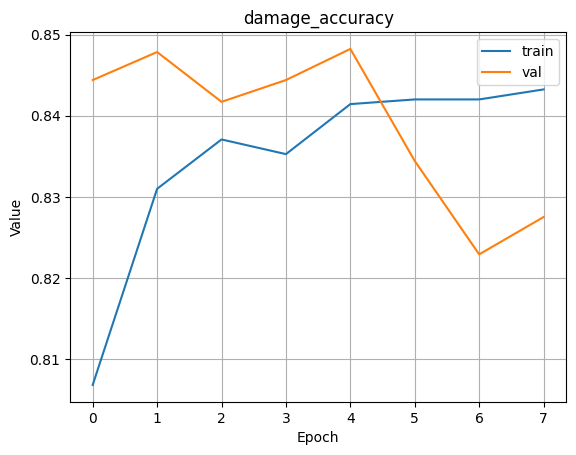

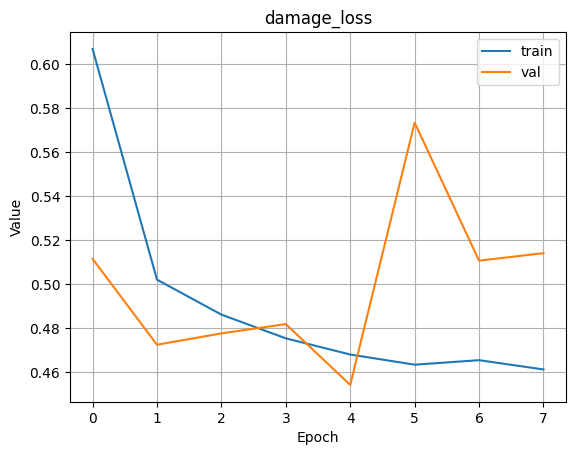

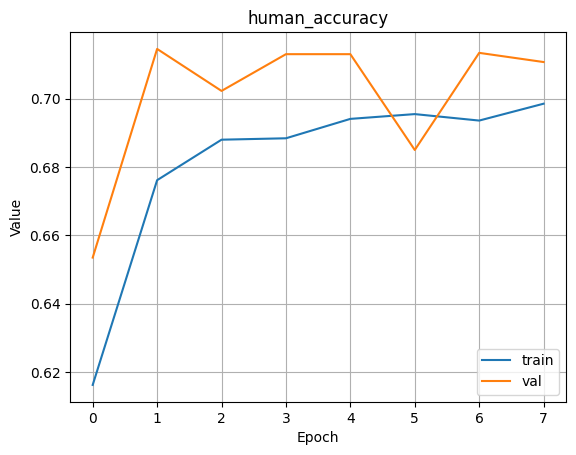

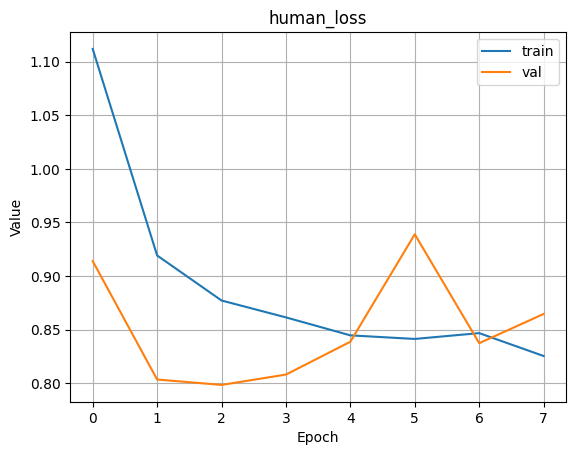

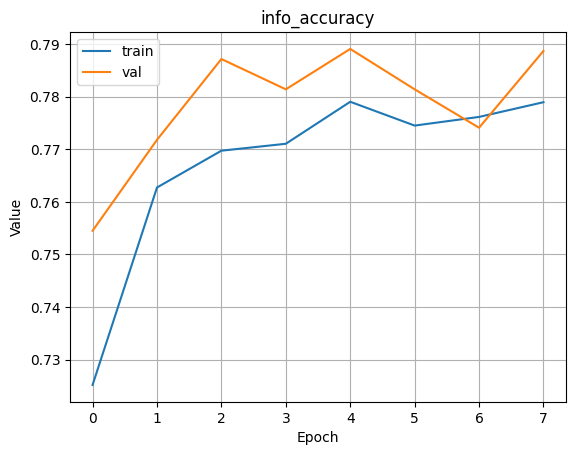

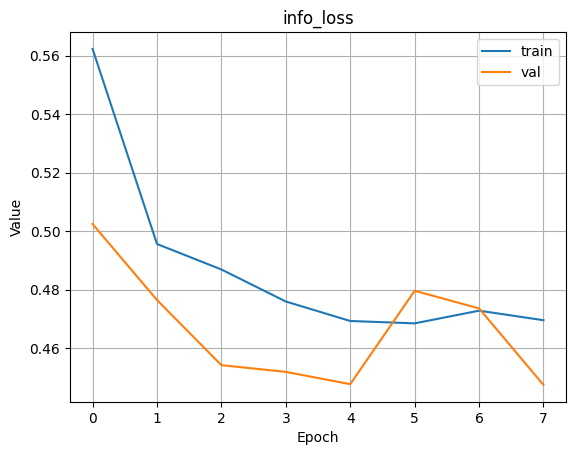

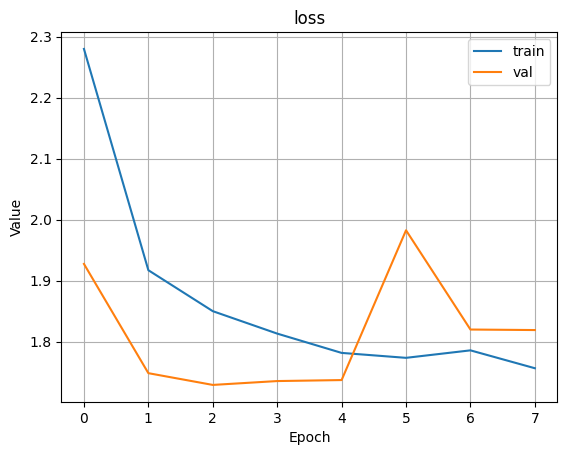

In [161]:
def plot_training_history(history):
    for key in history.history:
        if not key.startswith("val_"):
            plt.figure()
            plt.plot(history.history[key], label="train")
            plt.plot(history.history[f"val_{key}"], label="val")
            plt.title(key)
            plt.xlabel("Epoch")
            plt.ylabel("Value")
            plt.legend()
            plt.grid(True)
            plt.show()

plot_training_history(history)
